<a href="https://colab.research.google.com/github/soorya200314/EGFR-QSAR-Repurposing/blob/main/EGFR_QSAR_Repurposing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The goal is to build a model that predicts the IC50 (potency) of molecules against the Epidermal Growth Factor Receptor (EGFR), a major target in cancer nanomedicine. You will then use this model to "virtually screen" a set of unknown molecules to find potential drug candidates.

**Model Training**

In [ ]:
# Install necessary libraries
!pip install rdkit chembl_webresource_client pandas matplotlib xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from chembl_webresource_client.new_client import new_client

# 1. Search for EGFR Target
target = new_client.target
target_query = target.search('EGFR')
targets = pd.DataFrame.from_dict(target_query)

# We want the human EGFR (usually the first result)
selected_target = targets.target_chembl_id[0]
print(f"Selected Target ChEMBL ID: {selected_target}")

# 2. Retrieve Bioactivity Data (IC50)
activity = new_client.activity
res = activity.filter(target_chembl_id=selected_target).filter(standard_type="IC50")
df = pd.DataFrame.from_dict(res)

# 3. Quick Clean: Keep only SMILES and Standard Value
df = df.dropna(subset=['canonical_smiles', 'standard_value'])
df = df[['canonical_smiles', 'standard_value']]
df['standard_value'] = df['standard_value'].astype(float)

print(f"Retrieved {len(df)} compounds!")
df.head()

Selected Target ChEMBL ID: CHEMBL3608
Retrieved 94 compounds!


,canonical_smiles,standard_value
0,COc1cccc2c(C(=O)Nc3ccccc3)c(SSc3c(C(=O)Nc4cccc...,100000.0
1,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3ccccc3n2C)c(C(=O)N...,100000.0
2,CN1C(=S)C(C(=O)Nc2ccccc2)c2ccccc21,100000.0
3,Cn1c(SSc2c(C(=O)Nc3ccccc3)c3cccnc3n2C)c(C(=O)N...,25000.0
4,C/N=N/Nc1ccc2ncnc(Nc3cccc(Br)c3)c2c1,70.0


In [ ]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator

# 1. Log Transformation (nM to pIC50)
# We handle zero/negative values just in case of data errors
df = df[df['standard_value'] > 0]
df['pIC50'] = 9 - np.log10(df['standard_value'])

# 1. Initialize the Generator
# radius=2 is equivalent to ECFP4
# fpSize=2048 is the standard bit length
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def generate_fingerprints_modern(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        # The modern way to get a bit vector
        return np.array(morgan_gen.GetCountFingerprintAsNumPy(mol))
    return None

# Apply to your dataframe
print("Generating fingerprints with MorganGenerator...")
df['fp'] = df['canonical_smiles'].apply(generate_fingerprints_modern)

# Drop any rows where RDKit failed to parse the SMILES
df = df.dropna(subset=['fp'])

# 4. Final Formatting for XGBoost
# X = features (the matrix), y = label (pIC50)
X = np.stack(df['fp'].values)
y = df['pIC50'].values

print(f"Feature Matrix Shape: {X.shape}") # Should be (N, 2048)
print(f"Target Array Shape: {y.shape}")

Generating fingerprints with MorganGenerator...
Feature Matrix Shape: (94, 2048)
Target Array Shape: (94,)


In [ ]:
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors

# 1. Define the descriptors we want (all available in RDKit)
names = [desc[0] for desc in Descriptors._descList]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(names)

def get_physicochemical_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return np.array(calc.CalcDescriptors(mol))
    return None

# 2. Calculate for your dataframe
print("Calculating physical descriptors...")
df['descriptors'] = df['canonical_smiles'].apply(get_physicochemical_descriptors)

# 3. Create the "Fused" Matrix (Fingerprints + Descriptors)
X_fingerprints = np.stack(df['fp'].values)
X_descriptors = np.stack(df['descriptors'].values)

# Horizontal concatenation
X_combined = np.hstack([X_fingerprints, X_descriptors])

print(f"New Feature Matrix Shape: {X_combined.shape}")
# Likely (N, 2048 + 208)

Calculating physical descriptors...
New Feature Matrix Shape: (94, 2265)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_combined_scaled = scaler.fit_transform(X_combined)

In [ ]:
from sklearn.model_selection import train_test_split

# X_combined_scaled is your matrix from the previous step
X_train, X_test, y_train, y_test = train_test_split(
    X_combined_scaled, y, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 75
Test set size: 19


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the model
# Using some standard hyperparameters to start
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    n_jobs=-1,
    random_state=42
)

# Train the model
print("Training the model... this may take a moment.")
model.fit(X_train, y_train)

Training the model... this may take a moment.


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-squared: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

R-squared: 0.519
RMSE: 1.090


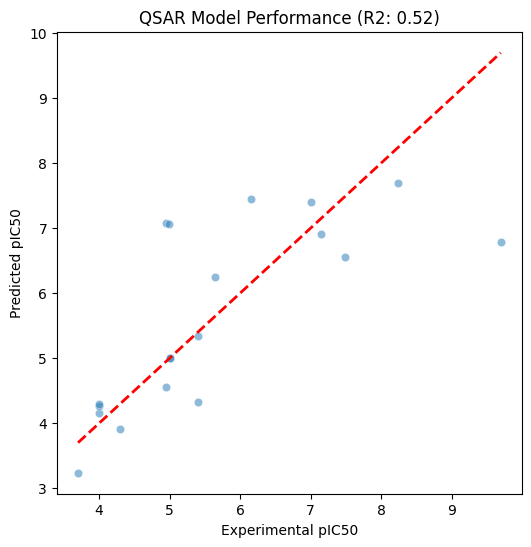

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Experimental pIC50")
plt.ylabel("Predicted pIC50")
plt.title(f"QSAR Model Performance (R2: {r2:.2f})")
plt.show()

**Screening**

In [ ]:
# 1. Access the Molecule client
molecule = new_client.molecule

# 2. Filter for molecules that have reached Clinical Phase 3 or 4
# This gives you high-quality, "drug-like" molecules
clinical_mols = molecule.filter(max_phase__gte=3)

# 3. Convert to DataFrame (limit to 2000 for speed)
clinical_df = pd.DataFrame.from_dict(clinical_mols[:2000])

# --- STEP 4 (From your previous code) ---
library_smiles = [m['canonical_smiles'] for m in clinical_df['molecule_structures'] if m]
print(f"Initial clinical-stage library: {len(library_smiles)} molecules")

# --- NEW STEP: DEDUPLICATION ---
# Get the set of SMILES used in your training data
# 'df' is the dataframe you used to train your XGBoost model
train_smiles_set = set(df['canonical_smiles'].tolist())

# Remove any molecules from the screening library that were in the training set
final_screening_library = [s for s in library_smiles if s not in train_smiles_set]

removed_count = len(library_smiles) - len(final_screening_library)
print(f"Removed {removed_count} molecules already present in training data.")
print(f"Final 'Unknown' library for screening: {len(final_screening_library)} molecules.")

Initial clinical-stage library: 1987 molecules
Removed 5 molecules already present in training data.
Final 'Unknown' library for screening: 1982 molecules.


In [ ]:
import numpy as np

def predict_library(smiles_list, model, scaler, morgan_gen, calc):
    preds = []
    valid_smiles = []

    print(f"Starting inference on {len(smiles_list)} molecules...")
    for i, smiles in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            # 1. Structural Features (Morgan)
            fp = np.array(morgan_gen.GetCountFingerprintAsNumPy(mol))

            # 2. Physical Features (Descriptors)
            phys = np.array(calc.CalcDescriptors(mol))

            # 3. Combine and Scale
            combined = np.hstack([fp, phys]).reshape(1, -1)
            scaled = scaler.transform(combined)

            # 4. Predict pIC50
            pIC50 = model.predict(scaled)[0]

            preds.append(pIC50)
            valid_smiles.append(smiles)

        if (i+1) % 500 == 0:
            print(f"Processed {i+1} molecules...")

    return pd.DataFrame({"SMILES": valid_smiles, "Predicted_pIC50": preds})

# Run the screen
screen_results = predict_library(final_screening_library, model, scaler, morgan_gen, calc)

Starting inference on 1982 molecules...
Processed 500 molecules...
Processed 1000 molecules...
Processed 1500 molecules...


In [ ]:
# 1. Get the top 10 hits
top_hits = screen_results.nlargest(10, 'Predicted_pIC50')

# 2. Function to look up names using ChEMBL Client
def get_chembl_name(smiles):
    try:
        res = molecule.filter(molecule_structures__canonical_smiles__iexact=smiles).only(['pref_name'])
        return res[0]['pref_name'] if res[0]['pref_name'] else "Unnamed / Code"
    except:
        return "Unknown"

# 3. Add names to your hits
top_hits['Drug_Name'] = top_hits['SMILES'].apply(get_chembl_name)
display(top_hits[['Drug_Name', 'Predicted_pIC50', 'SMILES']])

,Drug_Name,Predicted_pIC50,SMILES
1981,SALMETEROL XINAFOATE,9.094368,O=C(O)c1ccc2ccccc2c1O.OCc1cc(C(O)CNCCCCCCOCCCC...
1364,ZANAMIVIR,9.037340,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...
670,LACTULOSE,8.959388,OC[C@H]1O[C@@H](O[C@@H]2[C@@H](CO)O[C@](O)(CO)...
1494,SUCROSE,8.959215,OC[C@H]1O[C@@](CO)(O[C@H]2O[C@H](CO)[C@@H](O)[...
48,OLSALAZINE,8.947538,O=C(O)c1cc(/N=N/c2ccc(O)c(C(=O)O)c2)ccc1O
501,ADENOSINE PHOSPHATE,8.894561,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...
1385,KANAMYCIN SULFATE,8.883759,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...
1264,KANAMYCIN,8.879097,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...
1677,DORIPENEM,8.841168,C[C@@H](O)[C@H]1C(=O)N2C(C(=O)O)=C(S[C@@H]3CN[...
1564,ACARBOSE,8.823362,C[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O)[C@@H](O...


In [ ]:
# Run this to see versions
!pip freeze | grep -E "rdkit|xgboost|pandas|scikit-learn"

geopandas==1.1.3
pandas==2.2.2
pandas-datareader==0.10.0
pandas-gbq==0.30.0
pandas-stubs==2.2.2.240909
rdkit==2026.3.1
scikit-learn==1.6.1
sklearn-pandas==2.2.0
xgboost==3.2.0
